# ARC-v0.12 — Colab Cross-Policy Boundary Transfer

Post-confirmatory transfer audit built on the sealed ARC-v0.9 boundary study.

**Goal.** Test whether a boundary-risk predictor learned under one feedback-policy family transfers to the other family without target-family fitting.

Primary transfer directions:

- **mean → softmax**
- **softmax → mean**

Within-family controls:

- mean → mean
- softmax → softmax

The transfer model deliberately excludes family-indicator / temperature-only features and uses only features meaningful in both families:

- initial retrieval geometry: candidate divergence, utility gap, PQ32/SQ8 entropy and margins, entropy gap, margin gap
- shared feedback controls: alpha and k

The response variable remains the ARC-v0.9 **high-amplification** target, defined from the **source-family FIT split only** using the 75th percentile of H3 slope. The frozen source threshold is then applied unchanged to the target-family validation data.

Validation uncertainty is estimated by **query-cluster bootstrap**, so repeated configuration rows from the same query are never treated as independent bootstrap units.

## Hard safeguards

1. ARC-v0.9 must be reconstructed first.
2. The original v0.9 validation AUC must match the sealed report within `1e-6`.
3. No HotpotQA test retrieval or test qrels are accessed.
4. Transfer thresholds and model specifications are sealed before target-family validation metrics are computed.
5. Null and reversal cases are retained.
6. ARC-v0.11 M3 Max system measurements are not used here; this notebook is purely the Colab statistical lineage.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
%pip install -q faiss-cpu==1.12.0 psutil pyarrow scikit-learn matplotlib

In [9]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import platform
import sys

import numpy as np
import pandas as pd
import faiss
import sklearn
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
)

print('Python      :', sys.version.split()[0])
print('Platform    :', platform.platform())
print('FAISS       :', faiss.__version__)
print('NumPy       :', np.__version__)
print('pandas      :', pd.__version__)
print('scikit-learn:', sklearn.__version__)

Python      : 3.12.13
Platform    : Linux-6.6.122+-x86_64-with-glibc2.35
FAISS       : 1.12.0
NumPy       : 2.0.2
pandas      : 2.2.2
scikit-learn: 1.6.1


## 1. Paths and sealed provenance

In [10]:
SEED = 20260816
BOOTSTRAP_SAMPLES = 10_000
AUC_REPRO_TOL = 1e-6

ARC_ROOT = Path('/content/drive/MyDrive/rag-pq-checkpoints/arc-v0')

# Explicit sealed runs already established in the ARC lineage.
V09_RUN = ARC_ROOT / 'boundary-stability-map-v09' / '20260816-130217'
V010_RUN = ARC_ROOT / 'boundary-aware-selective-fidelity-v010' / '20260816-205143'

V09_REPORT = V09_RUN / 'report.json'
V09_PROTOCOL = V09_RUN / 'boundary_protocol.json'
V09_SPLIT = V09_RUN / 'boundary_query_split.csv'
V09_VALIDATION_ROWS = V09_RUN / 'boundary_validation_query_config_rows.parquet'
V09_COEFFICIENTS = V09_RUN / 'boundary_model_coefficients.csv'

required = {
    'V09_REPORT': V09_REPORT,
    'V09_PROTOCOL': V09_PROTOCOL,
    'V09_SPLIT': V09_SPLIT,
    'V09_VALIDATION_ROWS': V09_VALIDATION_ROWS,
    'V09_COEFFICIENTS': V09_COEFFICIENTS,
}

for name, path in required.items():
    print(f'{name:24s}', 'OK' if path.is_file() else 'MISSING', path)
    if not path.is_file():
        raise FileNotFoundError(path)

FIT_FILES = sorted(V09_RUN.glob('fit-*.parquet'))
assert len(FIT_FILES) == 44, len(FIT_FILES)
print('FIT files:', len(FIT_FILES))

with open(V09_REPORT, 'r', encoding='utf-8') as f:
    v09_report = json.load(f)

with open(V09_PROTOCOL, 'r', encoding='utf-8') as f:
    v09_protocol = json.load(f)

assert v09_report['status'] == 'ARC_V09_BOUNDARY_STABILITY_MAP_COMPLETE'
assert v09_report['test_accessed'] is False
assert v09_protocol['test_access_allowed'] is False

print('\nSEALED V0.9 PREFLIGHT — PASS')

V09_REPORT               OK /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/boundary-stability-map-v09/20260816-130217/report.json
V09_PROTOCOL             OK /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/boundary-stability-map-v09/20260816-130217/boundary_protocol.json
V09_SPLIT                OK /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/boundary-stability-map-v09/20260816-130217/boundary_query_split.csv
V09_VALIDATION_ROWS      OK /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/boundary-stability-map-v09/20260816-130217/boundary_validation_query_config_rows.parquet
V09_COEFFICIENTS         OK /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/boundary-stability-map-v09/20260816-130217/boundary_model_coefficients.csv
FIT files: 44

SEALED V0.9 PREFLIGHT — PASS


In [11]:
def sha256_file(path, chunk_size=64 * 1024 * 1024):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

print('v0.9 report SHA:', sha256_file(V09_REPORT))
print('v0.9 protocol SHA:', sha256_file(V09_PROTOCOL))

v0.9 report SHA: 1fb38e3e274a8b09e01af1543ed67ab604e6f702c086c6fb250939cb2fc50641
v0.9 protocol SHA: 201f7bc618486e3126eaa9a07f1eb32f1e727a270a76fc6747feb2266cbeb6d4


## 2. Reconstruct the exact ARC-v0.9 model table

In [12]:
# ============================================================
# 2. Reconstruct the exact ARC-v0.9 model table
#
# FIX:
# validation parquet contains BASE_FEATURES only for the
# validation split. We therefore reconstruct baseline features
# for ALL 5,447 DEV queries exactly from PQ32 / SQ8 retrieval.
# ============================================================

import sqlite3
import time

ROOT = Path(
    "/content/drive/MyDrive/"
    "hc-rars-external-confirmation-hotpotqa-5m-v1"
)

INDEX_ROOT = Path(
    "/content/drive/MyDrive/"
    "rag-pq-checkpoints/"
    "arc-index-cache/hotpotqa-rebuilt-v3"
)

QUERY_EMB = (
    ROOT
    / "stage1/query_embeddings.float32.npy"
)

QUERY_IDS = (
    ROOT
    / "stage1/query_ids.utf8.txt"
)

SPLIT_MANIFEST = (
    ROOT
    / "stage1/official_split_manifest.json"
)

CORPUS_DB = (
    ROOT
    / "stage1/corpus_ids.sqlite"
)

DEV_QRELS = (
    ROOT
    / "source/hotpotqa/qrels/dev.tsv"
)

PQ32_PATH = (
    INDEX_ROOT
    / (
        "hotpotqa-v3-5233329d-bge-small-"
        "ivfpq-nlist4096-m32-nbits8-seed20260816.faiss"
    )
)

SQ8_PATH = (
    INDEX_ROOT
    / (
        "hotpotqa-v3-5233329d-bge-small-"
        "ivfsq8-nlist4096-seed20260816.faiss"
    )
)


for name, path in {
    "QUERY_EMB": QUERY_EMB,
    "QUERY_IDS": QUERY_IDS,
    "SPLIT_MANIFEST": SPLIT_MANIFEST,
    "CORPUS_DB": CORPUS_DB,
    "DEV_QRELS": DEV_QRELS,
    "PQ32_INDEX": PQ32_PATH,
    "SQ8_INDEX": SQ8_PATH,
}.items():

    print(
        f"{name:20s}",
        "OK" if path.is_file() else "MISSING",
        path,
    )

    if not path.is_file():
        raise FileNotFoundError(path)


# ------------------------------------------------------------
# 1. Load exact HotpotQA DEV queries
# ------------------------------------------------------------

queries = np.load(
    QUERY_EMB,
    mmap_mode="r",
)

with open(
    QUERY_IDS,
    "r",
    encoding="utf-8",
) as f:

    query_ids = [
        x.strip()
        for x in f
        if x.strip()
    ]


with open(
    SPLIT_MANIFEST,
    "r",
    encoding="utf-8",
) as f:

    official_split = json.load(f)


dev_ids = [
    str(x)
    for x in official_split[
        "dev_query_ids"
    ]
]

assert len(dev_ids) == 5447

assert (
    official_split[
        "test_qrels_relevance_values_accessed"
    ]
    is False
)

assert (
    official_split[
        "test_retrieval_performed"
    ]
    is False
)

assert (
    official_split[
        "test_outcomes_observed"
    ]
    is False
)


query_row = {
    qid: i
    for i, qid in enumerate(
        query_ids
    )
}


dev_query_rows = np.asarray(
    [
        query_row[qid]
        for qid in dev_ids
    ],
    dtype=np.int64,
)


Q_DEV = np.asarray(
    queries[
        dev_query_rows
    ],
    dtype=np.float32,
)


Q_DEV /= np.maximum(
    np.linalg.norm(
        Q_DEV,
        axis=1,
        keepdims=True,
    ),
    1e-12,
)


print()
print(
    "queries total:",
    len(query_ids),
)

print(
    "DEV queries  :",
    len(dev_ids),
)

print(
    "Q_DEV shape  :",
    Q_DEV.shape,
)

assert Q_DEV.shape == (
    5447,
    384,
)

print(
    "DEV QUERY ALIGNMENT — PASS"
)


# ------------------------------------------------------------
# 2. Reconstruct DEV qrels row IDs exactly
# ------------------------------------------------------------

dev = pd.read_csv(
    DEV_QRELS,
    sep="\t",
)

dev[
    "query-id"
] = (
    dev[
        "query-id"
    ]
    .astype(str)
)

dev[
    "corpus-id"
] = (
    dev[
        "corpus-id"
    ]
    .astype(str)
)


unique_doc_ids = (
    dev[
        "corpus-id"
    ]
    .drop_duplicates()
    .tolist()
)


with sqlite3.connect(
    str(
        CORPUS_DB
    )
) as con:

    con.execute(
        """
        CREATE TEMP TABLE requested_ids (
            doc_id TEXT PRIMARY KEY
        )
        """
    )

    con.executemany(
        """
        INSERT INTO requested_ids(doc_id)
        VALUES (?)
        """,
        [
            (x,)
            for x
            in unique_doc_ids
        ],
    )

    mapped = pd.read_sql_query(
        """
        SELECT
            r.doc_id,
            d.row_id

        FROM requested_ids r

        LEFT JOIN documents d
            ON d.doc_id = r.doc_id
        """,
        con,
    )


assert (
    mapped[
        "row_id"
    ]
    .notna()
    .all()
)


mapped[
    "row_id"
] = (
    mapped[
        "row_id"
    ]
    .astype(
        np.int64
    )
)


dev = dev.merge(
    mapped,

    left_on=
        "corpus-id",

    right_on=
        "doc_id",

    how=
        "left",

    validate=
        "many_to_one",
)


dev = dev.rename(
    columns={
        "row_id":
            "corpus-row"
    }
)


dev[
    "corpus-row"
] = (
    dev[
        "corpus-row"
    ]
    .astype(
        np.int64
    )
)


dev_qrels = {

    str(qid): set(
        g.loc[
            g[
                "score"
            ] > 0,
            "corpus-row",
        ]
        .astype(
            np.int64
        )
        .tolist()
    )

    for qid, g
    in dev.groupby(
        "query-id"
    )
}


assert (
    len(
        dev_qrels
    )
    == 5447
)

print(
    "DEV QRELS ALIGNMENT — PASS"
)


# ------------------------------------------------------------
# 3. Exact v0.9 baseline feature helpers
# ------------------------------------------------------------

def jaccard_distance_rows(
    a,
    b,
):

    out = np.empty(
        len(a),
        np.float32,
    )

    for i in range(
        len(a)
    ):

        A = set(
            map(
                int,
                a[i],
            )
        )

        B = set(
            map(
                int,
                b[i],
            )
        )

        union = len(
            A | B
        )

        out[i] = (
            1.0
            -
            len(
                A & B
            )
            /
            max(
                union,
                1,
            )
        )

    return out


def score_entropy(
    scores,
    k=20,
):

    z = np.asarray(
        scores[
            :,
            :k,
        ],
        np.float64,
    )

    z -= z.max(
        axis=1,
        keepdims=True,
    )

    p = np.exp(
        np.clip(
            z,
            -60,
            60,
        )
    )

    p /= np.maximum(
        p.sum(
            axis=1,
            keepdims=True,
        ),
        1e-12,
    )

    return -np.sum(
        p
        *
        np.log(
            np.maximum(
                p,
                1e-12,
            )
        ),
        axis=1,
    )


def score_margin(
    scores,
):

    return np.asarray(
        scores[
            :,
            0,
        ]
        -
        scores[
            :,
            9,
        ],
        np.float32,
    )


def ndcg_at_10(
    qids,
    ids,
):

    discounts = (
        1.0
        /
        np.log2(
            np.arange(
                2,
                12,
            )
        )
    )

    out = np.zeros(
        len(qids),
        np.float32,
    )

    for i, qid in enumerate(
        qids
    ):

        rel = dev_qrels[
            str(qid)
        ]

        hits = np.asarray(
            [
                int(doc)
                in rel

                for doc
                in ids[
                    i,
                    :10,
                ]
            ],
            dtype=np.float64,
        )

        dcg = float(
            (
                hits
                *
                discounts
            )
            .sum()
        )

        ideal = min(
            len(rel),
            10,
        )

        idcg = float(
            discounts[
                :ideal
            ]
            .sum()
        )

        out[i] = (
            dcg
            /
            idcg

            if idcg
            else 0.0
        )

    return out


# ------------------------------------------------------------
# 4. Exact PQ32 / SQ8 baseline retrieval
# ------------------------------------------------------------

NPROBE = 64
TOP_RETRIEVE = 100

faiss.omp_set_num_threads(
    8
)

baseline_cache = {}


for name, path in {

    "PQ32":
        PQ32_PATH,

    "SQ8":
        SQ8_PATH,

}.items():

    print()
    print(
        "=" * 80
    )

    print(
        name
    )

    index = faiss.read_index(
        str(path)
    )

    index.nprobe = (
        NPROBE
    )

    t0 = time.perf_counter()

    scores, ids = (
        index.search(
            np.ascontiguousarray(
                Q_DEV,
                np.float32,
            ),
            TOP_RETRIEVE,
        )
    )

    dt = (
        time.perf_counter()
        - t0
    )


    ndcg = ndcg_at_10(
        dev_ids,
        ids,
    )


    baseline_cache[
        name
    ] = {

        "scores":
            scores,

        "ids":
            ids,

        "ndcg":
            ndcg,

        "entropy20":
            score_entropy(
                scores,
                20,
            ),

        "margin1_10":
            score_margin(
                scores
            ),
    }


    print(
        "seconds :",
        dt,
    )

    print(
        "nDCG@10:",
        float(
            ndcg.mean()
        ),
    )

    del index


# ------------------------------------------------------------
# 5. Reconstruct features for ALL 5,447 DEV queries
# ------------------------------------------------------------

pq = baseline_cache[
    "PQ32"
]

sq = baseline_cache[
    "SQ8"
]


features_df = pd.DataFrame({

    "query_id":
        dev_ids,

    "initial_candidate_divergence":
        jaccard_distance_rows(
            pq[
                "ids"
            ],
            sq[
                "ids"
            ],
        ),

    "initial_abs_utility_gap":
        np.abs(
            sq[
                "ndcg"
            ]
            -
            pq[
                "ndcg"
            ]
        ),

    "pq32_entropy20":
        pq[
            "entropy20"
        ],

    "sq8_entropy20":
        sq[
            "entropy20"
        ],

    "pq32_margin1_10":
        pq[
            "margin1_10"
        ],

    "sq8_margin1_10":
        sq[
            "margin1_10"
        ],

    "entropy_gap":
        np.abs(
            pq[
                "entropy20"
            ]
            -
            sq[
                "entropy20"
            ]
        ),

    "margin_gap":
        np.abs(
            pq[
                "margin1_10"
            ]
            -
            sq[
                "margin1_10"
            ]
        ),
})


features_df[
    "query_id"
] = (
    features_df[
        "query_id"
    ]
    .astype(str)
)


BASE_FEATURES = [

    "initial_candidate_divergence",

    "initial_abs_utility_gap",

    "pq32_entropy20",

    "sq8_entropy20",

    "pq32_margin1_10",

    "sq8_margin1_10",

    "entropy_gap",

    "margin_gap",
]


assert (
    len(
        features_df
    )
    == 5447
)

assert (
    features_df[
        "query_id"
    ]
    .nunique()
    == 5447
)

assert (
    features_df[
        BASE_FEATURES
    ]
    .notna()
    .all()
    .all()
)

print()
print(
    "ALL-DEV FEATURE RECONSTRUCTION — PASS"
)


# ------------------------------------------------------------
# 6. Audit against the sealed VALIDATION features
# ------------------------------------------------------------

saved_validation = pd.read_parquet(
    V09_VALIDATION_ROWS
)

saved_validation[
    "query_id"
] = (
    saved_validation[
        "query_id"
    ]
    .astype(str)
)


saved_one = (

    saved_validation[
        [
            "query_id"
        ]
        +
        BASE_FEATURES
    ]

    .drop_duplicates(
        "query_id"
    )

)


check = features_df.merge(

    saved_one,

    on=
        "query_id",

    how=
        "inner",

    suffixes=(
        "_reconstructed",
        "_saved",
    ),

    validate=
        "one_to_one",
)


assert (
    len(
        check
    )
    == 2694
)


FEATURE_TOLERANCES = {

    "initial_candidate_divergence":
        1e-8,

    "initial_abs_utility_gap":
        1e-8,

    "pq32_entropy20":
        5e-8,

    "sq8_entropy20":
        5e-8,

    "entropy_gap":
        5e-8,

    "pq32_margin1_10":
        2e-6,

    "sq8_margin1_10":
        2e-6,

    "margin_gap":
        2e-6,
}


for c in BASE_FEATURES:

    a = check[
        f"{c}_reconstructed"
    ].to_numpy(
        np.float64
    )

    b = check[
        f"{c}_saved"
    ].to_numpy(
        np.float64
    )

    diff = np.abs(
        a - b
    )

    max_diff = float(
        diff.max()
    )

    mean_diff = float(
        diff.mean()
    )

    tol = (
        FEATURE_TOLERANCES[
            c
        ]
    )

    print(

        f"{c:34s}",

        f"max={max_diff:.12g}",

        f"mean={mean_diff:.12g}",

        f"tol={tol:.1e}",

    )

    assert np.isfinite(
        a
    ).all()

    assert np.isfinite(
        b
    ).all()

    assert (
        max_diff
        <= tol
    ), (
        c,
        max_diff,
        tol,
    )


print()
print(
    "SEALED VALIDATION FEATURE AUDIT — PASS"
)


# ------------------------------------------------------------
# 7. Reconstruct FIT slopes from the 44 frozen FIT files
# ------------------------------------------------------------

def slope_rows_from_fit_file(
    path,
):

    df = pd.read_parquet(
        path
    )

    rows = []

    group_cols = [

        "query_id",

        "low",

        "high",

        "method",

        "alpha",

        "k",

        "temperature",

        "config_key",

    ]


    for keys, g in df.groupby(

        group_cols,

        dropna=False,

        sort=False,

    ):

        (
            qid,

            low,

            high,

            method,

            alpha,

            k,

            temp,

            cfg,

        ) = keys


        g = g.sort_values(
            "iteration"
        )

        x = g[
            "iteration"
        ].to_numpy(
            np.float64
        )


        def slope(
            col,
        ):

            return float(
                np.polyfit(

                    x,

                    g[
                        col
                    ].to_numpy(
                        np.float64
                    ),

                    1,

                )[0]
            )


        rows.append({

            "query_id":
                str(qid),

            "low":
                low,

            "high":
                high,

            "method":
                method,

            "alpha":
                float(alpha),

            "k":
                int(k),

            "temperature":
                temp,

            "config_key":
                cfg,

            "H1_slope":
                slope(
                    "query_divergence"
                ),

            "H2_slope":
                slope(
                    "candidate_increment"
                ),

            "H3_slope":
                slope(
                    "abs_utility_gap"
                ),
        })


    return pd.DataFrame(
        rows
    )


fit_slope_frames = []


for i, p in enumerate(
    FIT_FILES,
    1,
):

    slopes = (
        slope_rows_from_fit_file(
            p
        )
    )

    fit_slope_frames.append(
        slopes
    )

    if i in {
        1,
        10,
        20,
        30,
        40,
        44,
    }:

        print(

            f"[{i:02d}/44]",

            p.name,

            slopes.shape,

        )


fit_slopes = pd.concat(

    fit_slope_frames,

    ignore_index=True,

)


# ------------------------------------------------------------
# 8. Correct FIT merge
# ------------------------------------------------------------

fit_rows = fit_slopes.merge(

    features_df,

    on=
        "query_id",

    how=
        "left",

    validate=
        "many_to_one",

)


fit_rows[
    "is_softmax"
] = (
    fit_rows[
        "method"
    ]
    == "softmax"
).astype(
    float
)


fit_rows[
    "temperature_numeric"
] = (

    pd.to_numeric(
        fit_rows[
            "temperature"
        ],
        errors=
            "coerce",
    )

    .fillna(
        1.0
    )
)


# ------------------------------------------------------------
# 9. Validation rows remain the sealed artifact
# ------------------------------------------------------------

val_rows = (
    saved_validation
    .copy()
)


print()
print(
    "fit rows:",
    fit_rows.shape,
)

print(
    "val rows:",
    val_rows.shape,
)

print(
    "fit unique queries:",
    fit_rows[
        "query_id"
    ].nunique(),
)

print(
    "val unique queries:",
    val_rows[
        "query_id"
    ].nunique(),
)

print(
    "fit configs:",
    fit_rows[
        "config_key"
    ].nunique(),
)

print(
    "val configs:",
    val_rows[
        "config_key"
    ].nunique(),
)


# ------------------------------------------------------------
# 10. Hard completeness gates
# ------------------------------------------------------------

assert (
    fit_rows[
        "query_id"
    ].nunique()
    == 2753
)

assert (
    val_rows[
        "query_id"
    ].nunique()
    == 2694
)

assert (
    fit_rows[
        "config_key"
    ].nunique()
    == 44
)

assert (
    val_rows[
        "config_key"
    ].nunique()
    == 44
)


assert (
    fit_rows[
        BASE_FEATURES
    ]
    .notna()
    .all()
    .all()
)


assert (
    val_rows[
        BASE_FEATURES
    ]
    .notna()
    .all()
    .all()
)


print()
print(
    "V0.9 TABLE RECONSTRUCTION — PASS"
)

QUERY_EMB            OK /content/drive/MyDrive/hc-rars-external-confirmation-hotpotqa-5m-v1/stage1/query_embeddings.float32.npy
QUERY_IDS            OK /content/drive/MyDrive/hc-rars-external-confirmation-hotpotqa-5m-v1/stage1/query_ids.utf8.txt
SPLIT_MANIFEST       OK /content/drive/MyDrive/hc-rars-external-confirmation-hotpotqa-5m-v1/stage1/official_split_manifest.json
CORPUS_DB            OK /content/drive/MyDrive/hc-rars-external-confirmation-hotpotqa-5m-v1/stage1/corpus_ids.sqlite
DEV_QRELS            OK /content/drive/MyDrive/hc-rars-external-confirmation-hotpotqa-5m-v1/source/hotpotqa/qrels/dev.tsv
PQ32_INDEX           OK /content/drive/MyDrive/rag-pq-checkpoints/arc-index-cache/hotpotqa-rebuilt-v3/hotpotqa-v3-5233329d-bge-small-ivfpq-nlist4096-m32-nbits8-seed20260816.faiss
SQ8_INDEX            OK /content/drive/MyDrive/rag-pq-checkpoints/arc-index-cache/hotpotqa-rebuilt-v3/hotpotqa-v3-5233329d-bge-small-ivfsq8-nlist4096-seed20260816.faiss

queries total: 97852
DEV queries  : 54

## 3. Hard reproduction gate for the original ARC-v0.9 classifier

In [13]:
FULL_V09_FEATURES = [
    'initial_candidate_divergence',
    'initial_abs_utility_gap',
    'pq32_entropy20',
    'sq8_entropy20',
    'pq32_margin1_10',
    'sq8_margin1_10',
    'entropy_gap',
    'margin_gap',
    'alpha',
    'k',
    'is_softmax',
    'temperature_numeric',
]

expected_threshold = float(
    v09_report['validation_metrics']['fit_high_amplification_threshold']
)

reconstructed_threshold = float(
    np.quantile(fit_rows['H3_slope'].to_numpy(np.float64), 0.75)
)

print('reconstructed threshold:', reconstructed_threshold)
print('expected threshold     :', expected_threshold)
print('abs diff               :', abs(reconstructed_threshold - expected_threshold))

assert np.isclose(reconstructed_threshold, expected_threshold, atol=1e-12)

X_fit_v09 = fit_rows[FULL_V09_FEATURES].to_numpy(np.float64)
y_fit_v09_cont = fit_rows['H3_slope'].to_numpy(np.float64)
y_fit_v09 = (y_fit_v09_cont >= reconstructed_threshold).astype(int)

X_val_v09 = val_rows[FULL_V09_FEATURES].to_numpy(np.float64)
y_val_v09_cont = val_rows['H3_slope'].to_numpy(np.float64)
y_val_v09 = (y_val_v09_cont >= reconstructed_threshold).astype(int)

clf_v09 = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(
        C=0.5,
        max_iter=2000,
        class_weight='balanced',
    )),
])

clf_v09.fit(X_fit_v09, y_fit_v09)
p_val_v09 = clf_v09.predict_proba(X_val_v09)[:, 1]

reconstructed_auc = float(roc_auc_score(y_val_v09, p_val_v09))
expected_auc = float(v09_report['validation_metrics']['auc'])
auc_diff = abs(reconstructed_auc - expected_auc)

print('\nreconstructed validation AUC:', reconstructed_auc)
print('expected validation AUC     :', expected_auc)
print('abs diff                    :', auc_diff)

# This is deliberately a HARD gate. Do not relax for v0.12.
assert np.isclose(
    reconstructed_auc,
    expected_auc,
    atol=AUC_REPRO_TOL,
), (reconstructed_auc, expected_auc, auc_diff)

coef_saved = (
    pd.read_csv(V09_COEFFICIENTS)
    .set_index('feature')
    .loc[FULL_V09_FEATURES, 'logistic_standardized_coefficient']
    .to_numpy(np.float64)
)
coef_local = clf_v09.named_steps['model'].coef_[0].astype(np.float64)

coef_audit = pd.DataFrame({
    'feature': FULL_V09_FEATURES,
    'sealed': coef_saved,
    'reconstructed': coef_local,
    'abs_diff': np.abs(coef_saved - coef_local),
})

display(coef_audit)
print('max coefficient abs diff:', float(coef_audit['abs_diff'].max()))
print('\nV0.9 EXACT MODEL RECONSTRUCTION — PASS')

reconstructed threshold: 0.043681490421295155
expected threshold     : 0.043681490421295155
abs diff               : 0.0

reconstructed validation AUC: 0.7736072867396695
expected validation AUC     : 0.7736072913165861
abs diff                    : 4.5769166234777e-09


,feature,sealed,reconstructed,abs_diff
0,initial_candidate_divergence,-0.077172,-0.077172,1.075172e-08
1,initial_abs_utility_gap,-0.583788,-0.583788,6.649652e-09
2,pq32_entropy20,0.351252,0.351252,3.716862e-08
3,sq8_entropy20,-0.120906,-0.120906,7.619168e-10
4,pq32_margin1_10,-0.810835,-0.810834,6.671967e-07
5,sq8_margin1_10,1.824275,1.824273,1.304068e-06
6,entropy_gap,-0.306765,-0.306765,1.824058e-08
7,margin_gap,-0.448691,-0.448690,9.605149e-07
8,alpha,0.602401,0.602401,1.498219e-08
9,k,-0.048306,-0.048306,1.168105e-08


max coefficient abs diff: 1.3040680761911005e-06

V0.9 EXACT MODEL RECONSTRUCTION — PASS


## 4. Seal ARC-v0.12 protocol before transfer evaluation

The protocol below fixes the transfer design before computing target-family validation metrics.

**Primary endpoint:** target-family ROC-AUC for source-trained high-amplification prediction.

**Secondary endpoints:** average precision, accuracy at 0.5, and query-cluster bootstrap 95% CIs.

**Transfer success is not defined by an arbitrary p-value.** The notebook reports effect sizes and uncertainty, plus the gap to a target-family fit-only oracle comparator. This preserves positive, null, and negative transfer outcomes.

In [14]:
TRANSFER_FEATURES = [
    'initial_candidate_divergence',
    'initial_abs_utility_gap',
    'pq32_entropy20',
    'sq8_entropy20',
    'pq32_margin1_10',
    'sq8_margin1_10',
    'entropy_gap',
    'margin_gap',
    'alpha',
    'k',
]

TRANSFER_DIRECTIONS = [
    ('mean', 'mean'),
    ('mean', 'softmax'),
    ('softmax', 'softmax'),
    ('softmax', 'mean'),
]

protocol = {
    'status': 'ARC_V012_CROSS_POLICY_TRANSFER_SEALED_BEFORE_TARGET_EVALUATION',
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'source_v09_report': str(V09_REPORT),
    'source_v09_report_sha256': sha256_file(V09_REPORT),
    'source_v09_protocol_sha256': sha256_file(V09_PROTOCOL),
    'v09_exact_reproduction_auc': reconstructed_auc,
    'v09_expected_auc': expected_auc,
    'v09_auc_abs_diff': auc_diff,
    'training_split': 'ARC-v0.9 deterministic boundary FIT split only',
    'evaluation_split': 'ARC-v0.9 deterministic boundary VALIDATION split only',
    'transfer_features': TRANSFER_FEATURES,
    'excluded_family_specific_features': ['is_softmax', 'temperature_numeric'],
    'source_threshold_rule': '75th percentile of source-family FIT H3_slope, applied unchanged to validation target family',
    'classifier': {
        'type': 'StandardScaler + LogisticRegression',
        'C': 0.5,
        'max_iter': 2000,
        'class_weight': 'balanced',
    },
    'directions': [list(x) for x in TRANSFER_DIRECTIONS],
    'primary_metric': 'ROC-AUC',
    'secondary_metrics': ['average_precision', 'accuracy_at_0p5'],
    'bootstrap': {
        'unit': 'query_id cluster',
        'samples': BOOTSTRAP_SAMPLES,
        'ci': 0.95,
        'seed': SEED,
    },
    'retain_null_and_negative_transfer': True,
    'test_access_allowed': False,
}

raw = json.dumps(protocol, sort_keys=True, separators=(',', ':')).encode('utf-8')
protocol_sha = hashlib.sha256(raw).hexdigest()
protocol['protocol_sha256'] = protocol_sha

OUT_ROOT = ARC_ROOT / 'cross-policy-boundary-transfer-v012'
OUT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
OUT = OUT_ROOT / RUN_ID
OUT.mkdir(parents=True, exist_ok=False)

PROTOCOL_OUT = OUT / 'v012_transfer_protocol.json'
PROTOCOL_OUT.write_text(json.dumps(protocol, indent=2), encoding='utf-8')

print('ARC-v0.12 output:', OUT)
print('protocol SHA-256:', protocol_sha)
print('\nARC-v0.12 PROTOCOL — SEALED')

ARC-v0.12 output: /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/cross-policy-boundary-transfer-v012/20260817-131303
protocol SHA-256: 5789f053aa51a1bc830b7bb55a0ae95dc7f6dee91211e2353403ccb5b835848d

ARC-v0.12 PROTOCOL — SEALED


## 5. Build source/target family tables

In [15]:
def family_frame(df, family):
    x = df.loc[df['method'].astype(str) == family].copy()
    x['query_id'] = x['query_id'].astype(str)
    return x

fit_by_family = {
    fam: family_frame(fit_rows, fam)
    for fam in ['mean', 'softmax']
}
val_by_family = {
    fam: family_frame(val_rows, fam)
    for fam in ['mean', 'softmax']
}

for fam in ['mean', 'softmax']:
    print('\n', fam.upper())
    print('FIT       :', fit_by_family[fam].shape,
          'queries=', fit_by_family[fam]['query_id'].nunique(),
          'configs=', fit_by_family[fam]['config_key'].nunique())
    print('VALIDATION:', val_by_family[fam].shape,
          'queries=', val_by_family[fam]['query_id'].nunique(),
          'configs=', val_by_family[fam]['config_key'].nunique())

assert fit_by_family['mean']['config_key'].nunique() == 12
assert fit_by_family['softmax']['config_key'].nunique() == 32
assert val_by_family['mean']['config_key'].nunique() == 12
assert val_by_family['softmax']['config_key'].nunique() == 32

print('\nFAMILY TABLES — PASS')


 MEAN
FIT       : (33036, 21) queries= 2753 configs= 12
VALIDATION: (32328, 22) queries= 2694 configs= 12

 SOFTMAX
FIT       : (88096, 21) queries= 2753 configs= 32
VALIDATION: (86208, 22) queries= 2694 configs= 32

FAMILY TABLES — PASS


## 6. Train source-family models using FIT only

In [16]:
source_models = {}
source_thresholds = {}
source_fit_metrics = []

for source_family in ['mean', 'softmax']:
    src = fit_by_family[source_family]
    y_cont = src['H3_slope'].to_numpy(np.float64)
    threshold = float(np.quantile(y_cont, 0.75))
    y = (y_cont >= threshold).astype(int)
    X = src[TRANSFER_FEATURES].to_numpy(np.float64)

    clf = Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(
            C=0.5,
            max_iter=2000,
            class_weight='balanced',
        )),
    ])
    clf.fit(X, y)
    p = clf.predict_proba(X)[:, 1]

    source_models[source_family] = clf
    source_thresholds[source_family] = threshold
    source_fit_metrics.append({
        'source_family': source_family,
        'source_fit_threshold': threshold,
        'fit_rows': len(src),
        'fit_queries': src['query_id'].nunique(),
        'fit_positive_fraction': float(y.mean()),
        'fit_auc': float(roc_auc_score(y, p)),
        'fit_average_precision': float(average_precision_score(y, p)),
    })

source_fit_metrics = pd.DataFrame(source_fit_metrics)
display(source_fit_metrics)

# Freeze learned objects / thresholds in-memory before target evaluation.
print('SOURCE-FAMILY MODELS — FIT AND FROZEN')

,source_family,source_fit_threshold,fit_rows,fit_queries,fit_positive_fraction,fit_auc,fit_average_precision
0,mean,0.039781,33036,2753,0.250000,0.734600,0.455216
1,softmax,0.045259,88096,2753,0.251544,0.776094,0.534437


SOURCE-FAMILY MODELS — FIT AND FROZEN


## 7. Query-cluster bootstrap helpers

In [17]:
def safe_auc(y, p):
    if np.unique(y).size < 2:
        return np.nan
    return float(roc_auc_score(y, p))


def metric_triplet(y, p):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=np.float64)
    yhat = (p >= 0.5).astype(int)
    return {
        'auc': safe_auc(y, p),
        'average_precision': float(average_precision_score(y, p)),
        'accuracy_at_0p5': float(accuracy_score(y, yhat)),
    }


def clustered_bootstrap_metrics(pred_df, samples=10_000, seed=20260816):
    # Resample query IDs, carrying all config rows for each sampled query.
    rng = np.random.default_rng(seed)
    qids = pred_df['query_id'].drop_duplicates().to_numpy()

    grouped = {
        qid: g[['y', 'p']].to_numpy()
        for qid, g in pred_df.groupby('query_id', sort=False)
    }

    aucs = np.empty(samples, np.float64)
    aps = np.empty(samples, np.float64)
    accs = np.empty(samples, np.float64)

    for b in range(samples):
        sampled = rng.choice(qids, size=len(qids), replace=True)
        arr = np.concatenate([grouped[q] for q in sampled], axis=0)
        y = arr[:, 0].astype(int)
        p = arr[:, 1].astype(np.float64)

        aucs[b] = safe_auc(y, p)
        aps[b] = average_precision_score(y, p)
        accs[b] = accuracy_score(y, p >= 0.5)

    def ci(x):
        x = x[np.isfinite(x)]
        return float(np.quantile(x, 0.025)), float(np.quantile(x, 0.975))

    return {
        'auc_ci_low': ci(aucs)[0],
        'auc_ci_high': ci(aucs)[1],
        'average_precision_ci_low': ci(aps)[0],
        'average_precision_ci_high': ci(aps)[1],
        'accuracy_ci_low': ci(accs)[0],
        'accuracy_ci_high': ci(accs)[1],
    }

print('BOOTSTRAP HELPERS — READY')

BOOTSTRAP HELPERS — READY


## 8. Primary cross-policy transfer evaluation

In [18]:
prediction_frames = []
summary_rows = []

for direction_idx, (source_family, target_family) in enumerate(TRANSFER_DIRECTIONS):
    target = val_by_family[target_family].copy()
    threshold = source_thresholds[source_family]
    clf = source_models[source_family]

    X = target[TRANSFER_FEATURES].to_numpy(np.float64)
    y = (target['H3_slope'].to_numpy(np.float64) >= threshold).astype(int)
    p = clf.predict_proba(X)[:, 1]

    pred = target[[
        'query_id', 'config_key', 'method', 'alpha', 'k', 'temperature', 'H3_slope'
    ]].copy()
    pred['source_family'] = source_family
    pred['target_family'] = target_family
    pred['source_threshold'] = threshold
    pred['y'] = y
    pred['p'] = p
    prediction_frames.append(pred)

    point = metric_triplet(y, p)
    ci = clustered_bootstrap_metrics(
        pred[['query_id', 'y', 'p']],
        samples=BOOTSTRAP_SAMPLES,
        seed=SEED + direction_idx,
    )

    summary_rows.append({
        'source_family': source_family,
        'target_family': target_family,
        'is_cross_policy': source_family != target_family,
        'source_threshold': threshold,
        'target_rows': len(target),
        'target_queries': target['query_id'].nunique(),
        'target_positive_fraction': float(y.mean()),
        **point,
        **ci,
    })

predictions = pd.concat(prediction_frames, ignore_index=True)
transfer_summary = pd.DataFrame(summary_rows)

print('PRIMARY TRANSFER RESULTS')
display(transfer_summary)

PRIMARY TRANSFER RESULTS


,source_family,target_family,is_cross_policy,source_threshold,target_rows,target_queries,target_positive_fraction,auc,average_precision,accuracy_at_0p5,auc_ci_low,auc_ci_high,average_precision_ci_low,average_precision_ci_high,accuracy_ci_low,accuracy_ci_high
0,mean,mean,False,0.039781,32328,2694,0.246752,0.740677,0.455635,0.665615,0.729883,0.751166,0.440099,0.471772,0.656366,0.674524
1,mean,softmax,True,0.039781,86208,2694,0.272539,0.766532,0.544860,0.674775,0.756424,0.776532,0.529303,0.560286,0.665924,0.683707
2,softmax,softmax,False,0.045259,86208,2694,0.248968,0.783017,0.532766,0.699181,0.773422,0.792447,0.516503,0.548818,0.690968,0.707290
3,softmax,mean,True,0.045259,32328,2694,0.224388,0.755019,0.435071,0.686711,0.745265,0.764847,0.418815,0.451678,0.678359,0.695063


## 9. Target-family fit-only oracle comparator

This comparator is **not** used to choose or alter the transfer model. It quantifies how much discrimination is lost when the target family is unavailable during model fitting.

For each target family, a model is fitted only on that family's ARC-v0.9 FIT rows and evaluated on that family's validation rows. Its threshold is the target-family FIT 75th percentile, exactly parallel to the source-family construction.

In [19]:
oracle_rows = []

for target_family in ['mean', 'softmax']:
    fit_target = fit_by_family[target_family]
    val_target = val_by_family[target_family]

    threshold = float(np.quantile(fit_target['H3_slope'].to_numpy(np.float64), 0.75))
    y_fit = (fit_target['H3_slope'].to_numpy(np.float64) >= threshold).astype(int)
    X_fit = fit_target[TRANSFER_FEATURES].to_numpy(np.float64)

    clf = Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(
            C=0.5,
            max_iter=2000,
            class_weight='balanced',
        )),
    ])
    clf.fit(X_fit, y_fit)

    X_val = val_target[TRANSFER_FEATURES].to_numpy(np.float64)
    y_val = (val_target['H3_slope'].to_numpy(np.float64) >= threshold).astype(int)
    p_val = clf.predict_proba(X_val)[:, 1]
    point = metric_triplet(y_val, p_val)

    oracle_rows.append({
        'target_family': target_family,
        'oracle_threshold': threshold,
        'oracle_auc': point['auc'],
        'oracle_average_precision': point['average_precision'],
        'oracle_accuracy_at_0p5': point['accuracy_at_0p5'],
    })

oracle_summary = pd.DataFrame(oracle_rows)
display(oracle_summary)

transfer_summary = transfer_summary.merge(
    oracle_summary,
    on='target_family',
    how='left',
    validate='many_to_one',
)
transfer_summary['auc_gap_to_target_oracle'] = (
    transfer_summary['auc'] - transfer_summary['oracle_auc']
)
transfer_summary['ap_gap_to_target_oracle'] = (
    transfer_summary['average_precision'] - transfer_summary['oracle_average_precision']
)

display(transfer_summary)

,target_family,oracle_threshold,oracle_auc,oracle_average_precision,oracle_accuracy_at_0p5
0,mean,0.039781,0.740677,0.455635,0.665615
1,softmax,0.045259,0.783017,0.532766,0.699181


,source_family,target_family,is_cross_policy,source_threshold,target_rows,target_queries,target_positive_fraction,auc,average_precision,accuracy_at_0p5,...,average_precision_ci_low,average_precision_ci_high,accuracy_ci_low,accuracy_ci_high,oracle_threshold,oracle_auc,oracle_average_precision,oracle_accuracy_at_0p5,auc_gap_to_target_oracle,ap_gap_to_target_oracle
0,mean,mean,False,0.039781,32328,2694,0.246752,0.740677,0.455635,0.665615,...,0.440099,0.471772,0.656366,0.674524,0.039781,0.740677,0.455635,0.665615,0.000000,0.000000
1,mean,softmax,True,0.039781,86208,2694,0.272539,0.766532,0.544860,0.674775,...,0.529303,0.560286,0.665924,0.683707,0.045259,0.783017,0.532766,0.699181,-0.016485,0.012094
2,softmax,softmax,False,0.045259,86208,2694,0.248968,0.783017,0.532766,0.699181,...,0.516503,0.548818,0.690968,0.707290,0.045259,0.783017,0.532766,0.699181,0.000000,0.000000
3,softmax,mean,True,0.045259,32328,2694,0.224388,0.755019,0.435071,0.686711,...,0.418815,0.451678,0.678359,0.695063,0.039781,0.740677,0.455635,0.665615,0.014342,-0.020564


## 10. Cross-policy transfer contrasts

In [20]:
# Compare each cross-policy direction against the corresponding within-family source control.
# Example: mean→softmax is compared with mean→mean to measure source-model transfer degradation.
within_auc = {
    row['source_family']: row['auc']
    for _, row in transfer_summary.loc[~transfer_summary['is_cross_policy']].iterrows()
}

transfer_summary['auc_change_vs_source_within_family'] = [
    float(row['auc'] - within_auc[row['source_family']])
    for _, row in transfer_summary.iterrows()
]

cross_policy = transfer_summary.loc[transfer_summary['is_cross_policy']].copy()
print('CROSS-POLICY PRIMARY CONTRASTS')
display(cross_policy[[
    'source_family',
    'target_family',
    'auc',
    'auc_ci_low',
    'auc_ci_high',
    'average_precision',
    'auc_gap_to_target_oracle',
    'auc_change_vs_source_within_family',
]])

CROSS-POLICY PRIMARY CONTRASTS


,source_family,target_family,auc,auc_ci_low,auc_ci_high,average_precision,auc_gap_to_target_oracle,auc_change_vs_source_within_family
1,mean,softmax,0.766532,0.756424,0.776532,0.544860,-0.016485,0.025854
3,softmax,mean,0.755019,0.745265,0.764847,0.435071,0.014342,-0.027997


## 11. Regime-preserving diagnostics

In [21]:
EPS = float(v09_report['regime_threshold_abs_slope'])

def regime(x):
    if x > EPS:
        return 'amplifying'
    if x < -EPS:
        return 'reversal'
    return 'stable_or_null'

predictions['regime'] = [regime(x) for x in predictions['H3_slope']]

regime_summary = (
    predictions
    .groupby(['source_family', 'target_family', 'regime'], as_index=False)
    .agg(
        rows=('query_id', 'size'),
        queries=('query_id', 'nunique'),
        mean_predicted_risk=('p', 'mean'),
        mean_h3_slope=('H3_slope', 'mean'),
    )
)

print('NULL / REVERSAL CASES RETAINED')
display(regime_summary)

NULL / REVERSAL CASES RETAINED


,source_family,target_family,regime,rows,queries,mean_predicted_risk,mean_h3_slope
0,mean,mean,amplifying,12844,2101,0.539672,0.064363
1,mean,mean,reversal,8831,1956,0.412591,-0.057229
2,mean,mean,stable_or_null,10653,2014,0.423632,-0.000001
3,mean,softmax,amplifying,36467,2154,0.558189,0.069087
4,mean,softmax,reversal,21124,1918,0.401894,-0.056475
5,mean,softmax,stable_or_null,28617,2068,0.428918,0.000001
6,softmax,mean,amplifying,12844,2101,0.523769,0.064363
7,softmax,mean,reversal,8831,1956,0.398422,-0.057229
8,softmax,mean,stable_or_null,10653,2014,0.382078,-0.000001
9,softmax,softmax,amplifying,36467,2154,0.544721,0.069087


## 12. Figures

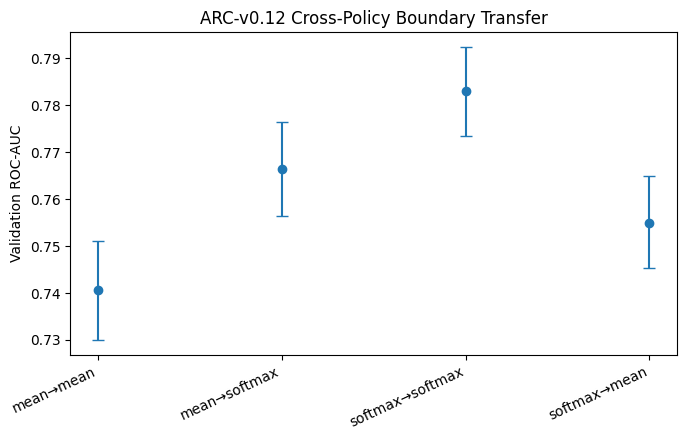

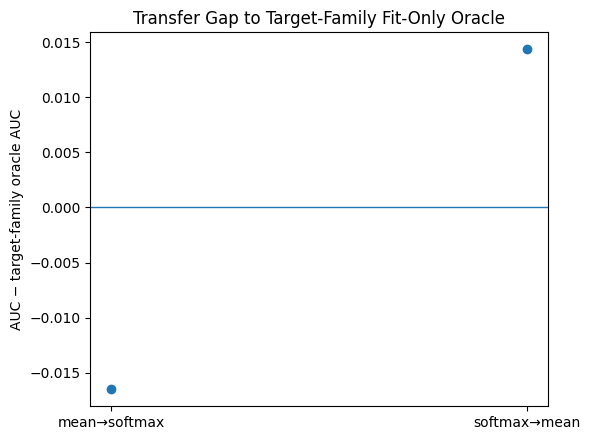

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_df = transfer_summary.copy()
labels = [f"{s}→{t}" for s, t in zip(plot_df['source_family'], plot_df['target_family'])]
err_low = plot_df['auc'] - plot_df['auc_ci_low']
err_high = plot_df['auc_ci_high'] - plot_df['auc']
ax.errorbar(
    np.arange(len(plot_df)),
    plot_df['auc'],
    yerr=np.vstack([err_low, err_high]),
    fmt='o',
    capsize=4,
)
ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(labels, rotation=25, ha='right')
ax.set_ylabel('Validation ROC-AUC')
ax.set_title('ARC-v0.12 Cross-Policy Boundary Transfer')
fig.tight_layout()
FIG_AUC = OUT / 'v012_cross_policy_auc.png'
fig.savefig(FIG_AUC, dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
cross = transfer_summary.loc[transfer_summary['is_cross_policy']].copy()
ax.axhline(0.0, linewidth=1)
ax.scatter(
    [f"{s}→{t}" for s, t in zip(cross['source_family'], cross['target_family'])],
    cross['auc_gap_to_target_oracle'],
)
ax.set_ylabel('AUC − target-family oracle AUC')
ax.set_title('Transfer Gap to Target-Family Fit-Only Oracle')
fig.tight_layout()
FIG_GAP = OUT / 'v012_transfer_gap_to_oracle.png'
fig.savefig(FIG_GAP, dpi=180, bbox_inches='tight')
plt.show()

## 13. Seal artifacts and final report

In [23]:
SOURCE_FIT_OUT = OUT / 'v012_source_fit_metrics.csv'
SUMMARY_OUT = OUT / 'v012_transfer_summary.csv'
CROSS_OUT = OUT / 'v012_cross_policy_primary_contrasts.csv'
PRED_OUT = OUT / 'v012_transfer_predictions.parquet'
REGIME_OUT = OUT / 'v012_regime_summary.csv'
ORACLE_OUT = OUT / 'v012_target_family_oracle_summary.csv'

source_fit_metrics.to_csv(SOURCE_FIT_OUT, index=False)
transfer_summary.to_csv(SUMMARY_OUT, index=False)
cross_policy.to_csv(CROSS_OUT, index=False)
predictions.to_parquet(PRED_OUT, index=False)
regime_summary.to_csv(REGIME_OUT, index=False)
oracle_summary.to_csv(ORACLE_OUT, index=False)

cross_records = cross_policy[[
    'source_family', 'target_family',
    'auc', 'auc_ci_low', 'auc_ci_high',
    'average_precision',
    'auc_gap_to_target_oracle',
    'auc_change_vs_source_within_family',
]].to_dict(orient='records')

report = {
    'status': 'ARC_V012_CROSS_POLICY_BOUNDARY_TRANSFER_COMPLETE',
    'protocol_sha256': protocol_sha,
    'source_v09_report_sha256': sha256_file(V09_REPORT),
    'source_v09_protocol_sha256': sha256_file(V09_PROTOCOL),
    'v09_exact_reproduction': {
        'expected_auc': expected_auc,
        'reconstructed_auc': reconstructed_auc,
        'absolute_difference': auc_diff,
        'tolerance': AUC_REPRO_TOL,
        'passed': bool(auc_diff <= AUC_REPRO_TOL),
    },
    'transfer_feature_count': len(TRANSFER_FEATURES),
    'transfer_features': TRANSFER_FEATURES,
    'cross_policy_results': cross_records,
    'bootstrap_samples': BOOTSTRAP_SAMPLES,
    'bootstrap_unit': 'query_id cluster',
    'retain_null_and_reversal_cases': True,
    'test_accessed': False,
    'interpretation': (
        'Post-confirmatory cross-policy transfer audit. '
        'Positive, null, and negative transfer outcomes are retained. '
        'No target-family validation result was used to tune the source-family models.'
    ),
    'completed_at_utc': datetime.now(timezone.utc).isoformat(),
}

REPORT_OUT = OUT / 'report.json'
REPORT_OUT.write_text(json.dumps(report, indent=2, default=float), encoding='utf-8')
report_sha = sha256_file(REPORT_OUT)
(OUT / 'REPORT_SHA256.txt').write_text(report_sha + '\n', encoding='utf-8')

artifact_rows = []
for p in sorted(OUT.iterdir()):
    if p.is_file():
        artifact_rows.append({
            'file': p.name,
            'bytes': p.stat().st_size,
            'sha256': sha256_file(p),
        })
artifact_manifest = pd.DataFrame(artifact_rows)
artifact_manifest.to_csv(OUT / 'ARTIFACT_MANIFEST_SHA256.csv', index=False)

print('\n' + '=' * 80)
print('ARC-v0.12 CROSS-POLICY BOUNDARY TRANSFER — COMPLETE')
print('Output:', OUT)
print('Report SHA-256:', report_sha)
print('=' * 80)

display(cross_policy)
display(artifact_manifest)


ARC-v0.12 CROSS-POLICY BOUNDARY TRANSFER — COMPLETE
Output: /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/cross-policy-boundary-transfer-v012/20260817-131303
Report SHA-256: 77e8582c74c71748b8deca85f1f5d652b2db517d5927339706677db4fd87ab01


,source_family,target_family,is_cross_policy,source_threshold,target_rows,target_queries,target_positive_fraction,auc,average_precision,accuracy_at_0p5,...,average_precision_ci_high,accuracy_ci_low,accuracy_ci_high,oracle_threshold,oracle_auc,oracle_average_precision,oracle_accuracy_at_0p5,auc_gap_to_target_oracle,ap_gap_to_target_oracle,auc_change_vs_source_within_family
1,mean,softmax,True,0.039781,86208,2694,0.272539,0.766532,0.544860,0.674775,...,0.560286,0.665924,0.683707,0.045259,0.783017,0.532766,0.699181,-0.016485,0.012094,0.025854
3,softmax,mean,True,0.045259,32328,2694,0.224388,0.755019,0.435071,0.686711,...,0.451678,0.678359,0.695063,0.039781,0.740677,0.455635,0.665615,0.014342,-0.020564,-0.027997


,file,bytes,sha256
0,REPORT_SHA256.txt,65,75d9e679f1b22738da52b3a1c5a1be2022483f52c0c65a...
1,report.json,1997,77e8582c74c71748b8deca85f1f5d652b2db517d592733...
2,v012_cross_policy_auc.png,66519,5a99fad7f2116657a377bb7aad2e6f60117146b067b224...
3,v012_cross_policy_primary_contrasts.csv,1178,b35d8a04ebe3f1a18bf9480ccbc5b9323ad60a122c71c3...
4,v012_regime_summary.csv,1000,fff42229aa83a109b13f452891a176b58391a2f251444e...
5,v012_source_fit_metrics.csv,286,4ee1fcef8d9197769439b35fb45e31f2184baa6f593264...
6,v012_target_family_oracle_summary.csv,258,d4c8ca2a72b909349101a9a35861c34ce21db30a77e974...
7,v012_transfer_gap_to_oracle.png,46834,26891fe1fbf44ef8d7e8c7a9be1e7202aab595347a8fb3...
8,v012_transfer_predictions.parquet,1459351,206b382a37f42698948ec8527c1cb09c67837972d621ed...
9,v012_transfer_protocol.json,1928,b836da1d153f6b0f5aeb996f8f7ba50ef2802e6574717d...


## Interpretation discipline

Do **not** convert this audit into a positive-result-only story.

Paper-facing interpretation should distinguish:

- **within-family discrimination** — whether boundary risk is predictable in the same feedback family;
- **cross-policy transfer** — whether a source-family model preserves discrimination in the other family;
- **gap to target-family oracle** — how much is lost by forbidding target-family fitting;
- **null / reversal regimes** — retained as part of the mechanism boundary rather than filtered out.

A cross-policy AUC above 0.5 is evidence of some transferable ranking signal, but it is not by itself evidence of deployment usefulness. Deployment claims must remain tied to ARC-v0.10 mitigation and ARC-v0.11/0.11.1 system-cost evidence, which are separate experimental lineages.
